In [1]:
# Diabetes Classification — Evaluation & Final Comparison

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

In [3]:
# Reload & Reclean

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv("pima_diabetes.csv", header=None, names=columns)

zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
for col in zero_check_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_medians = X_train[zero_check_cols].median()
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()
for col in zero_check_cols:
    X_train_imputed[col] = X_train_imputed[col].fillna(train_medians[col])
    X_test_imputed[col] = X_test_imputed[col].fillna(train_medians[col])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
X_train_trees = X_train_imputed.values
X_test_trees = X_test_imputed.values

print("Ready. Train:", X_train.shape, "Test:", X_test.shape)

Ready. Train: (614, 8) Test: (154, 8)


In [4]:
# Retrain All 4 Tuned Models

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [3, 4, 5, 6, 8, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    cv=5, scoring="accuracy", n_jobs=-1
)
dt_grid.fit(X_train_trees, y_train)
dt_best = dt_grid.best_estimator_

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 200], "max_depth": [4, 6, 8, None], "max_features": ["sqrt", "log2"]},
    cv=5, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train_trees, y_train)
rf_best = rf_grid.best_estimator_

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": list(range(3, 25, 2)), "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
    cv=5, scoring="accuracy", n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.01, 0.1]},
    cv=5, scoring="accuracy", n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_

print("All 4 models trained.")

All 4 models trained.


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [5]:
model_objects = {
    "Decision Tree": (dt_best, X_test_trees),
    "Random Forest": (rf_best, X_test_trees),
    "KNN": (knn_best, X_test_scaled),
    "SVM": (svm_best, X_test_scaled)
}

model_predictions = {name: model.predict(X_test_input) for name, (model, X_test_input) in model_objects.items()}
model_probs = {name: model.predict_proba(X_test_input)[:, 1] for name, (model, X_test_input) in model_objects.items()}

In [6]:
# Full Metrics Per Model


results = []
for name, pred in model_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, model_probs[name])
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.7662,0.6957,0.5926,0.6400,0.8210
1,KNN,0.7468,0.6667,0.5556,0.6061,0.8077
2,SVM,0.6948,0.5814,0.4630,0.5155,0.8151
3,Decision Tree,0.6883,0.6364,0.2593,0.3684,0.7641


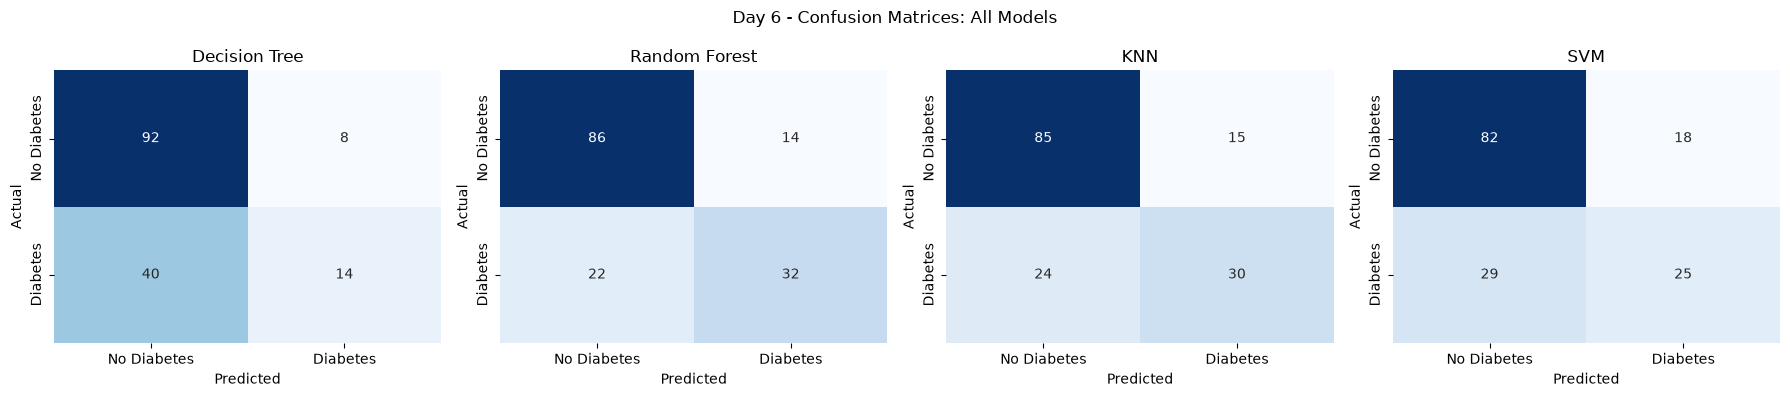

In [7]:
# Confusion Matrix — All 4 Models Side by Side

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"], cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Day 6 - Confusion Matrices: All Models")
plt.tight_layout()
plt.show()

In [8]:
# Detailed Classification Reports

for name, pred in model_predictions.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, pred, target_names=["No Diabetes", "Diabetes"]))

--- Decision Tree ---
              precision    recall  f1-score   support

 No Diabetes       0.70      0.92      0.79       100
    Diabetes       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154

--- Random Forest ---
              precision    recall  f1-score   support

 No Diabetes       0.80      0.86      0.83       100
    Diabetes       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154

--- KNN ---
              precision    recall  f1-score   support

 No Diabetes       0.78      0.85      0.81       100
    Diabetes       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg      

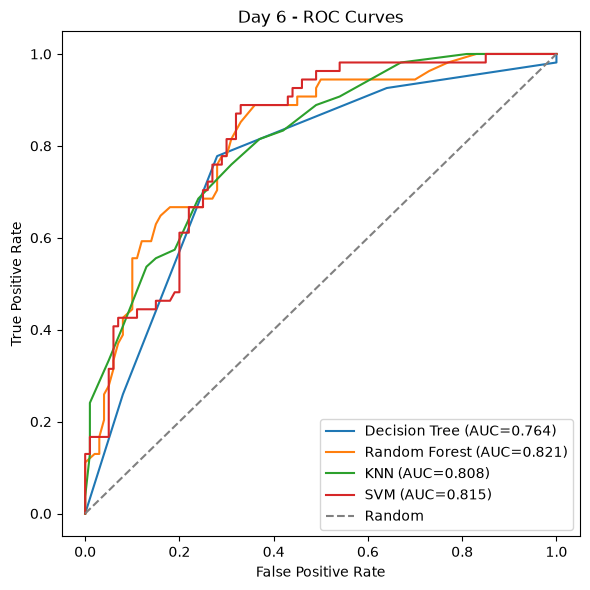

In [9]:
# ROC Curves — All Models

plt.figure(figsize=(6, 6))
for name in model_predictions.keys():
    fpr, tpr, _ = roc_curve(y_test, model_probs[name])
    auc = roc_auc_score(y_test, model_probs[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Day 6 - ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

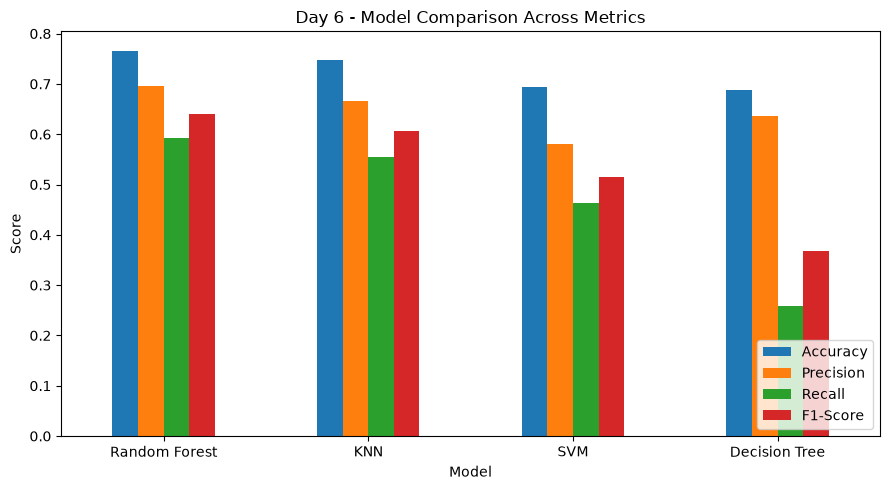

In [11]:
plt.figure(figsize=(9, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Score")
plt.title("Day 6 - Model Comparison Across Metrics")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()